In [15]:
from tensorflow import keras
from tensorflow.keras import layers

In [16]:

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),
    layers.Dense(10, activation="softmax")
])

In [19]:
model.save("")

AttributeError: module 'keras._tf_keras.keras' has no attribute 'saving'

In [21]:
import pickle
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Load CIFAR-10 test batch
def load_cifar10_batch(file):
    with open(file, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    return batch[b'data'], batch[b'labels']

X_test, y_test = load_cifar10_batch('cifar-10/test_batch')

# Reshape and normalize (same preprocessing as training!)
X_test = X_test.reshape(-1, 32, 32, 3).astype('float32') / 255.0
y_test = np.array(y_test)

# Load your saved model
model = keras.models.load_model('your_model.keras')  # or .h5

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test loss:     {loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0995 - loss: 2.3036
Test accuracy: 0.1000
Test loss:     2.3039


true_label 3
Original
→ cat (10.83%)
Untargeted attack
→ cat (10.61%)
Targeted attack (→ ship)
→ cat (10.78%)


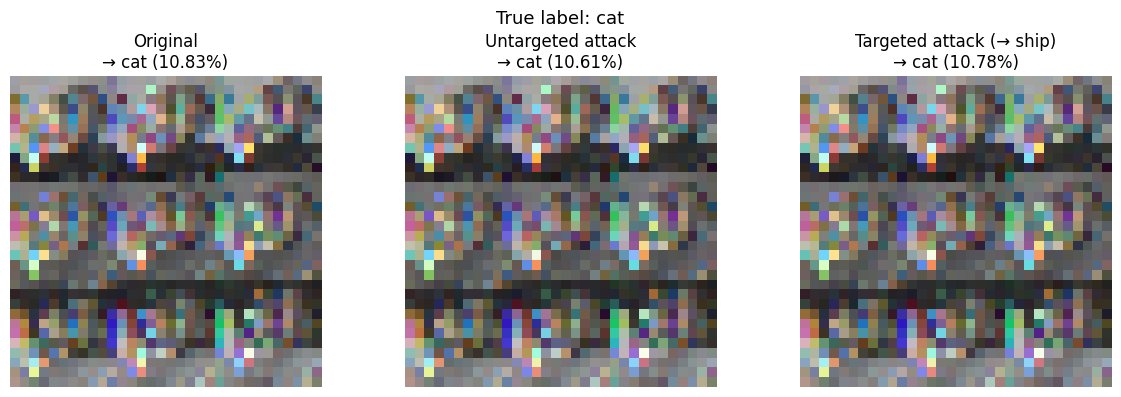

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Pick a single test image
idx = 0
image = X_test[idx:idx+1]  # shape (1, 32, 32, 3)
true_label = y_test[idx]

cifar10_classes = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

epsilon = 0.01  # attack strength

def get_prediction(img):
    pred = model.predict(img, verbose=0)
    return np.argmax(pred), np.max(pred)

def fgsm_untargeted(image, true_label, epsilon):
    image_tensor = tf.Variable(image, dtype=tf.float32)
    label_tensor = tf.cast([true_label], tf.int32)
    with tf.GradientTape() as tape:
        pred = model(image_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label_tensor, pred)
    gradient = tape.gradient(loss, image_tensor)
    perturbation = epsilon * tf.sign(gradient)
    adv_image = tf.clip_by_value(image_tensor + perturbation, 0, 1)
    return adv_image.numpy()

def fgsm_targeted(image, target_label, epsilon):
    image_tensor = tf.Variable(image, dtype=tf.float32)
    label_tensor = tf.cast([target_label], tf.int32)
    with tf.GradientTape() as tape:
        pred = model(image_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label_tensor, pred)
    gradient = tape.gradient(loss, image_tensor)
    perturbation = epsilon * tf.sign(gradient)
    adv_image = tf.clip_by_value(image_tensor - perturbation, 0, 1)
    return adv_image.numpy()

target_label = 8  # force model to predict "ship" (pick anything != true_label)
print(f"true_label {true_label}")
adv_untargeted = fgsm_untargeted(image, true_label, epsilon)
adv_targeted   = fgsm_targeted(image, target_label, epsilon)

orig_class,    orig_conf    = get_prediction(image)
untarg_class,  untarg_conf  = get_prediction(adv_untargeted)
targ_class,    targ_conf    = get_prediction(adv_targeted)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image[0])
axes[0].set_title(f"Original\n→ {cifar10_classes[orig_class]} ({orig_conf:.2%})")
print(f"Original\n→ {cifar10_classes[orig_class]} ({orig_conf:.2%})")

axes[1].imshow(adv_untargeted[0])
axes[1].set_title(f"Untargeted attack\n→ {cifar10_classes[untarg_class]} ({untarg_conf:.2%})")
print(f"Untargeted attack\n→ {cifar10_classes[untarg_class]} ({untarg_conf:.2%})")

axes[2].imshow(adv_targeted[0])
axes[2].set_title(f"Targeted attack (→ {cifar10_classes[target_label]})\n→ {cifar10_classes[targ_class]} ({targ_conf:.2%})")
print(f"Targeted attack (→ {cifar10_classes[target_label]})\n→ {cifar10_classes[targ_class]} ({targ_conf:.2%})")

for ax in axes:
    ax.axis('off')

plt.suptitle(f"True label: {cifar10_classes[true_label]}", fontsize=13)
plt.tight_layout()
plt.show()